In [13]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
import seaborn as sns

In [14]:
time_series_data = pd.read_csv(r'C:\myfols\MSC\sem2\TSP\AirPassengers.xls')

In [15]:
time_series_data.head()

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [16]:
time_series_data.shape

(144, 2)

In [17]:
#convert 'Month' column to datetime
time_series_data['Month'] = pd.to_datetime(time_series_data['Month'])
time_series_data = time_series_data.set_index('Month')

In [19]:
time_series_data.head() 

,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [20]:
time_series_data.shape

(144, 1)

Text(0, 0.5, '#Passengers')

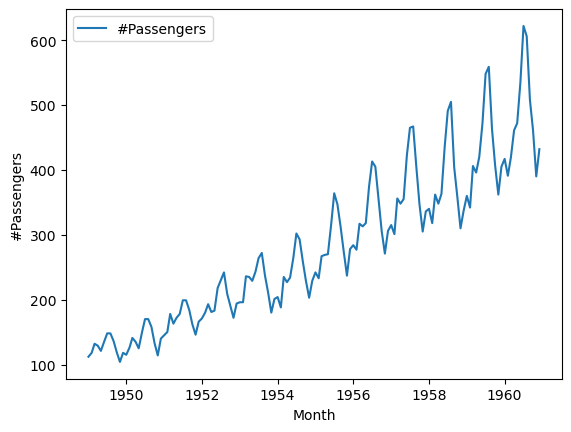

In [21]:
sns.lineplot(time_series_data)
plt.ylabel("#Passengers")

we will use multiplicative model since trend and seasonality are amplifying

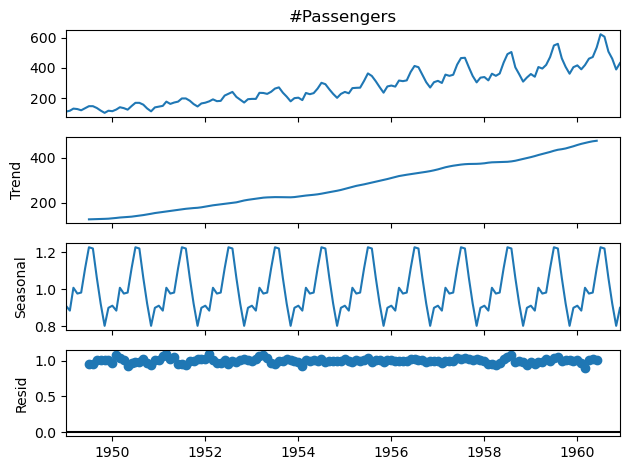

In [23]:
## Decomposition of Time Series Data - multiplicative model
result = seasonal_decompose(time_series_data['#Passengers'], model='multiplicative', period=12)
result.plot()
plt.show()

In [24]:
pip install pymannkendall

Note: you may need to restart the kernel to use updated packages.


In [25]:
import pymannkendall as mk

## Perform Mann-Kendall Trend Test
## H0: There is no monotonic trend in the series

mk.original_test(time_series_data['#Passengers'])


Mann_Kendall_Test(trend='increasing', h=np.True_, p=np.float64(0.0), z=np.float64(14.381610025544802), Tau=np.float64(0.8087606837606838), s=np.float64(8327.0), var_s=np.float64(335164.3333333333), slope=np.float64(2.451216287678477), intercept=np.float64(90.23803543098887))

# p=np.float64(0.0)
p value is less than 0.5 therefore we reject the h0 hence there is monotonic trend in the series.

In [26]:
## train test split
train_df = int(len(time_series_data) * 0.7)
test_df = len(time_series_data) - train_df

In [32]:
train_df

100

In [33]:
test_df

44